# Wolfram cellular automaton

## General informations 

### Some context...
Cellular automata are simple mathematical models that can generate surprisingly complex behavior from very simple rules. One of the most famous examples is Stephen Wolfram’s elementary cellular automata, which consist of a one-dimensional line of cells that can be either 0 (dead) or 1 (alive). At each step, the state of every cell is updated simultaneously according to a fixed rule that depends only on the cell itself and its two immediate neighbors. Despite the simplicity of this setup, Wolfram showed that these automata can display a wide variety of patterns, ranging from stable repetition to chaotic and fractal-like structures.

In this exercise, you will implement Wolfram’s cellular automata in Python using only NumPy. The goal is to simulate the evolution of a one-dimensional line of cells for a given number of steps, starting from an initial configuration and applying a rule (encoded as an integer between 0 and 255). By the end, your code should be able to display the evolving pattern over time, allowing you to explore the fascinating world of emergent complexity from minimal ingredients.

### Some additionnal references... 
 - This ressource [[1]](https://mathworld.wolfram.com/ElementaryCellularAutomaton.html) explains with more details what is Wolfram cellular automata, and explore in particular bitwise operations, an approach that will not be explored in this exercice. 
- The Wikipedia page of cellular automaton [[2]](https://en.wikipedia.org/wiki/Cellular_automaton) is more general and gives examples of other cellular automata (abr. CA) such as Conway's Game Of Life.

### Import packages

In [1]:
import numpy as np
import matplotlib.pyplot as plt

### Global variables used in the simulation

In [2]:
SIZE = 101 # Needs to be an odd number
STEPS = 100 # Number of steps for simulation
RULE_NUMBER = 30 # Can be any integer between 0-255, we'll start with rule 30 for the rest of the problem

## Question 1 : 
- Generate an array of size `SIZE`, full of dead cells
- Activate the center cell

In [8]:
state = 

## Question 2 : 
- Using a built-in `numpy` function (search in the documentation), or an implementation of your own, convert the rule `RULE_NUMBER` into its 8-bits binary representation
    - In this example, 30 = (**0** * *2<sup>7</sup>*) + (**0** * *2<sup>6</sup>*) + (**0** * *2<sup>5</sup>*) + (**1** * *2<sup>4</sup>*) + (**1** * *2<sup>3</sup>*) + (**1** * *2<sup>2</sup>*) + (**1** * *2<sup>1</sup>*) + (**0** * *2<sup>0</sup>*)
- The resulting array should be an array of `int` containing all 8 bits   

rule_bin is 00011110, and the type is <class 'str'>
[0 0 0 1 1 1 1 0]


Each cell in the automaton looks at itself and its two nearest neighbors (left and right) to determine its next state. This gives 2<sup>3</sup> = 8 possible neighborhood configurations (from 111 down to 000). 

The rule number, in binary, encodes what the next state should be for each configuration. For Rule 30, the binary representation of 30 is 00011110. 
Reading this sequence from left to right, it tells us that a neighborhood of 111 maps to 0, 110 maps to 0, 101 maps to 0, 100 maps to 1, and so on, until 000 maps to 0. 

By applying this mapping simultaneously to all cells, the automaton evolves into a new row of cells, and repeating this process step after step generates the full pattern.

A visual example is given below : 

<div align="center">

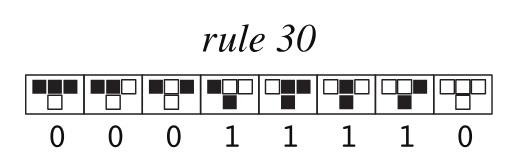

</div>

## Boundary conditions: a cyclic array

Before implementing the evolution of the cellular automaton, we need to specify what happens at the two boundaries of the array.

In this exercise, the array is **cyclic** (or periodic): the cell at the left boundary considers the cell at the right boundary as its left neighbour, and the cell at the right boundary considers the cell at the left boundary as its right neighbour.

For example, for the array

```text
[0 1 1 0 1]
```

the neighbours of the first cell are `(1, 0, 1)`, while the neighbours of the last cell are `(1, 1, 0)`.

You will need to take this periodic boundary condition into account when constructing the `left`, `center` and `right` arrays.

## Question 3 : Apply a Wolfram rule

The goal of this question is to create an `evolve()` function that returns the state of the cellular automaton after one iteration.

### Question 3.1 — Find one specific neighbourhood

To simplify the problem, consider only one possible 3-bit neighbourhood: **`101`**.

Starting from a state array, construct the `left`, `center` and `right` arrays while taking the cyclic boundary conditions into account.

Then:

- Create a NumPy **boolean mask** that is `True` exactly where the three neighbouring cells form the pattern `101`.
- Use this mask to identify the cells whose neighbourhood is `101`.
- Test your mask on a small example and check that it selects the expected cells.

**Hint:** a mask can be constructed by combining several boolean conditions with `&`, for example:

```python
mask = (left == ...) & (center == ...) & (right == ...)
```

### Question 3.2 — Generalise to all neighbourhoods

There are 8 possible 3-bit neighbourhoods:

`111`, `110`, `101`, `100`, `011`, `010`, `001`, `000`.

Generalise your previous approach by:

- defining these 8 patterns in the same order as the 8 entries of `rule_array`;
- looping over all patterns;
- creating a boolean mask for each pattern;
- using the corresponding value in `rule_array` to determine the new state of the selected cells.

Finally, encapsulate your implementation in an `evolve(state, rule_array)` function that returns the new state.

**Hint:** you can store the patterns as a list of tuples such as `(1, 1, 1)`, `(1, 1, 0)`, etc.

In [10]:
def evolve(state, rule_array):
    '''
    Return the state of the cellular automaton after one iteration.
    The boundary conditions are periodic (cyclic).
    '''
    return new_state


## Question 4

Define a `history` array, that stores the evolution of the system. Then, iterate on `STEPS` to make the system evolve, keeping track of all steps

In [12]:
history = 

## Question 5 
Using `plt.imshow()` and a black & white `cmap`, plot the evolution of the system

## Question 6 — Explore other Wolfram rules

Now that you have a working `evolve()` function, write a new function that **encapsulates the complete simulation** for a given Wolfram rule number.

Your function should:

- take a `rule_number` as an argument;
- create the initial state, with only the central cell alive;
- convert the rule number into its 8-bit representation;
- evolve the cellular automaton for `STEPS` iterations;
- store the history of the system;
- plot the resulting space-time diagram.

Then **call your function several times**, using different rule numbers that you find interesting. Choose rules that produce visibly different behaviours and compare the patterns you obtain.

For example, you could investigate rules that produce simple, periodic, symmetric, chaotic or more complex-looking patterns. You do not need to use a predefined list: **choose the rules yourself and explain briefly why you find them interesting.**

In [3]:
def run_rule(rule_number):
    return history, rule_bin